In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    cohen_kappa_score,
    recall_score
)

from xgboost import XGBClassifier, plot_importance

In [3]:
!unzip auracheck.zip

Archive:  auracheck.zip
   creating: auracheck/
  inflating: __MACOSX/._auracheck    
   creating: auracheck/Database/
   creating: auracheck/Unsupervised/
  inflating: auracheck/INTERNAL_SETUP.md  
   creating: auracheck/EDA/
  inflating: auracheck/.DS_Store     
  inflating: auracheck/requirements.txt  
  inflating: auracheck/.pre-commit-config.yaml  
   creating: auracheck/Dataset/
   creating: auracheck/xgboost/
   creating: auracheck/.streamlit/
   creating: auracheck/baseline/
   creating: auracheck/.devcontainer/
  inflating: auracheck/README.md     
  inflating: auracheck/.gitignore    
   creating: auracheck/scripts/
  inflating: auracheck/app.py        
   creating: auracheck/Documents/
  inflating: auracheck/.env.example  
   creating: auracheck/.git/
  inflating: auracheck/Database/script.sql  
  inflating: auracheck/Database/Tablenames  
  inflating: auracheck/Database/auracheck.db  
  inflating: auracheck/Database/supabase_fix_for_app_sqlite_auth.sql  
  inflating: aurach

In [4]:

df = pd.read_csv("/content/auracheck/Dataset/students_mental_health_survey_with_burnout_final.csv")
print(df.shape)

(10000, 29)


In [2]:
def find_repo_root(start=None):
    """Walk up from current working directory until the baseline dataset is found."""
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "Dataset" / "students_mental_health_survey_with_burnout_final.csv").exists():
            return cand
    raise FileNotFoundError("Could not locate repository root containing Dataset/students_mental_health_survey_with_burnout_final.csv")

ROOT_PATH = find_repo_root()
ROOT = str(ROOT_PATH)
DATA_PATH = str(ROOT_PATH / "Dataset" / "students_mental_health_survey_with_burnout_final.csv")

df = pd.read_csv(DATA_PATH)
print('Dataset: Dataset/students_mental_health_survey_with_burnout_final.csv')
print('Shape:', df.shape)

FileNotFoundError: Could not locate repository root containing Dataset/students_mental_health_survey_with_burnout_final.csv

In [5]:
df = pd.read_csv(find_repo_root() / "Dataset" / "students_mental_health_survey_with_burnout_final.csv")
df.head()

FileNotFoundError: Could not locate repository root containing Dataset/students_mental_health_survey_with_burnout_final.csv

In [6]:

ENCODING_MAP = {
    "Sleep_Quality": {"Poor": 0, "Average": 1, "Good": 2},
    "Physical_Activity": {"Low": 0, "Moderate": 1, "High": 2},
    "Diet_Quality": {"Good": 0, "Average": 1, "Poor": 2},
    "Social_Support": {"High": 0, "Moderate": 1, "Low": 2},
    "Substance_Use": {"Never": 0, "Unknown": 1, "Occasionally": 2, "Frequently": 3},
    "Counseling_Service_Use": {"Never": 0, "Occasionally": 1, "Frequently": 2},
    "Family_History": {"No": 0, "Yes": 1},
    "Chronic_Illness": {"No": 0, "Yes": 1},
    "Extracurricular_Involvement": {"High": 0, "Moderate": 1, "Low": 2},
}

In [7]:
def preprocess(df):
    drop_cols = [
        "burnout_composite_score",
        "burnout",
        "burnout_raw_score",
        "method1_tertiles",
        "method2_wider",
        "method3_very_wide",
        "method4_manual",
        "method5_manual2",
        "method6_kmeans",
        "Stress_Level",
        "Depression_Score",
        "Anxiety_Score",
    ]

    X = df.drop(columns=drop_cols, errors="ignore").copy()

    # Fill missing values
    for c in X.columns:
        if X[c].isnull().any():
            if X[c].dtype == object:
                X[c] = X[c].fillna("Unknown")
            else:
                X[c] = X[c].fillna(X[c].median())

    # Ordinal / binary encoding
    for c, m in ENCODING_MAP.items():
        if c in X.columns:
            X[c] = X[c].astype(str).map(m)

    # One-hot encoding
    cat_cols = ["Course", "Gender", "Relationship_Status", "Residence_Type"]
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    return X.astype(float)

In [8]:
X = preprocess(df)

y = pd.qcut(
    df["burnout_raw_score"].astype(float),
    q=4,
    labels=[0, 1, 2, 3],
    duplicates="drop"
).astype(int)

print(X.shape)
print(y.value_counts().sort_index())

(10000, 23)
burnout_raw_score
0    3028
1    2760
2    2330
3    1882
Name: count, dtype: int64


In [9]:
print([col for col in X.columns if "burnout" in col.lower()])

[]


In [10]:
print(X.columns)

Index(['Age', 'CGPA', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality',
       'Social_Support', 'Substance_Use', 'Counseling_Service_Use',
       'Family_History', 'Chronic_Illness', 'Financial_Stress',
       'Extracurricular_Involvement', 'Semester_Credit_Load',
       'Course_Computer Science', 'Course_Engineering', 'Course_Law',
       'Course_Medical', 'Course_Others', 'Gender_Male',
       'Relationship_Status_Married', 'Relationship_Status_Single',
       'Residence_Type_On-Campus', 'Residence_Type_With Family'],
      dtype='object')


In [11]:
#class imbalance handling
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = dict(zip(classes, weights))

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8000, 23)
Test shape: (2000, 23)


In [12]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

#sample weights are used to give more importance to minority classes during training, helping the model learn from imbalanced data.
sample_weights = y.map(class_weights)

xgb.fit(X_train, y_train, sample_weight=sample_weights.loc[y_train.index])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=4, ...)

In [13]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
kappa = cohen_kappa_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Macro Recall:", round(macro_recall, 4))
print("Cohen's Kappa:", round(kappa, 4))

Accuracy: 0.2725
Macro F1: 0.2675
Macro Recall: 0.2692
Cohen's Kappa: 0.0238


In [15]:
class_names = ["Very Low (Q1)", "Low (Q2)", "Moderate (Q3)", "High (Q4)"]

print(classification_report(y_test, y_pred, target_names=class_names))

               precision    recall  f1-score   support

Very Low (Q1)       0.35      0.34      0.34       606
     Low (Q2)       0.26      0.24      0.25       552
Moderate (Q3)       0.23      0.22      0.23       466
    High (Q4)       0.23      0.28      0.25       376

     accuracy                           0.27      2000
    macro avg       0.27      0.27      0.27      2000
 weighted avg       0.27      0.27      0.27      2000



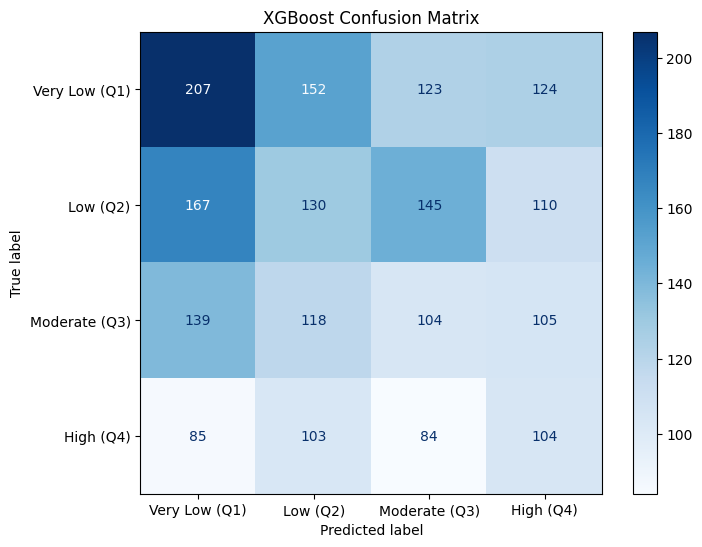

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.show()


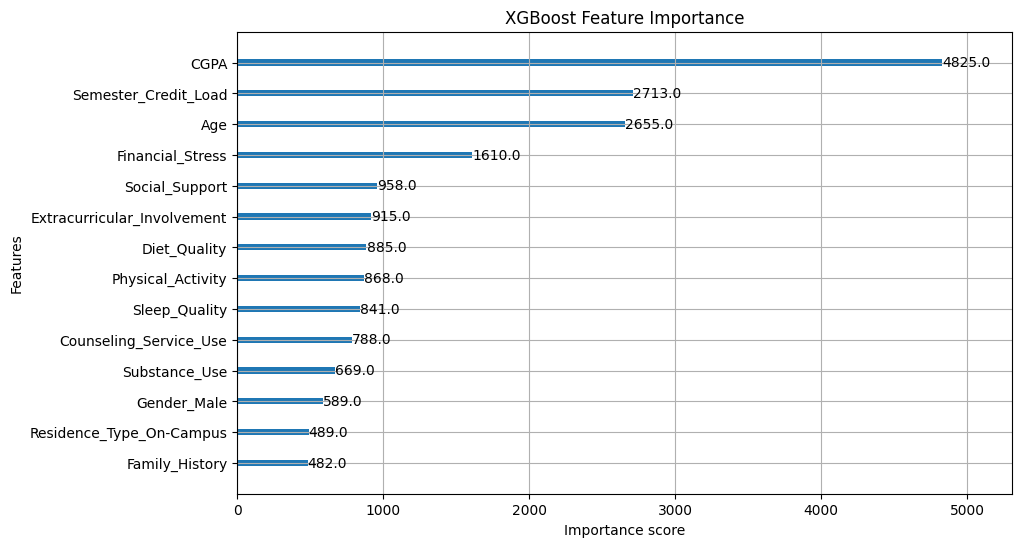

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(xgb, ax=ax, max_num_features=14)
plt.title("XGBoost Feature Importance")
plt.show()

In [47]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    "n_estimators": [80, 100, 120, 150],
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.05, 0.07],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "min_child_weight": [3, 5, 7],
    "gamma": [0.5, 1, 1.5],
    "reg_alpha": [0.25, 0.5, 1],
    "reg_lambda": [1.5, 2, 3]
}

xgb_tune = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist"
)

random = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random.fit(X_train, y_train, sample_weight=sample_weights.loc[y_train.index])

print("Best params:", random.best_params_)
print("Best CV score:", random.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.25, 'n_estimators': 80, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.07, 'gamma': 1, 'colsample_bytree': 0.9}
Best CV score: 0.2664419567803674


In [48]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss

best_xgb = random.best_estimator_

y_pred_best = best_xgb.predict(X_test)
probs = best_xgb.predict_proba(X_test)

accuracy_best = accuracy_score(y_test, y_pred_best)
macro_f1_best = f1_score(y_test, y_pred_best, average="macro")
macro_recall_best = recall_score(y_test, y_pred_best, average="macro")
kappa_best = cohen_kappa_score(y_test, y_pred_best)
roc_auc = roc_auc_score(y_test, probs, multi_class="ovr")
ll = log_loss(y_test, probs)

print("Tuned XGBoost Results")
print("Accuracy:", round(accuracy_best, 4))
print("Macro F1:", round(macro_f1_best, 4))
print("Macro Recall:", round(macro_recall_best, 4))
print("Cohen's Kappa:", round(kappa_best, 4))
print("ROC-AUC OvR:", round(roc_auc, 4))
print("Log Loss:", round(ll, 4))

Tuned XGBoost Results
Accuracy: 0.2765
Macro F1: 0.2654
Macro Recall: 0.2771
Cohen's Kappa: 0.0376
ROC-AUC OvR: 0.5245
Log Loss: 1.3836


In [41]:
results_df = X_test.copy()

results_df["true_label"] = y_test.values
results_df["predicted_label"] = y_pred_best


for i in range(probs.shape[1]):
    results_df[f"prob_class_{i}"] = probs[:, i]

results_df.to_csv("xgboost_predictions.csv", index=False)

In [42]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Macro Recall", "Kappa", "ROC-AUC OvR", "Log Loss"],
    "Value": [accuracy_best, macro_f1_best, macro_recall_best, kappa_best, roc_auc, ll]
})

metrics_df.to_csv("xgboost_metrics.csv", index=False)

In [43]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_best, output_dict=True)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv("xgboost_classification_report.csv")

report_df

,precision,recall,f1-score,support
0,0.362500,0.334983,0.348199,606.000
1,0.262500,0.190217,0.220588,552.000
2,0.203320,0.210300,0.206751,466.000
3,0.229391,0.340426,0.274090,376.000
accuracy,0.267000,0.267000,0.267000,0.267
macro avg,0.264428,0.268982,0.262407,2000.000
weighted avg,0.272786,0.267000,0.266089,2000.000


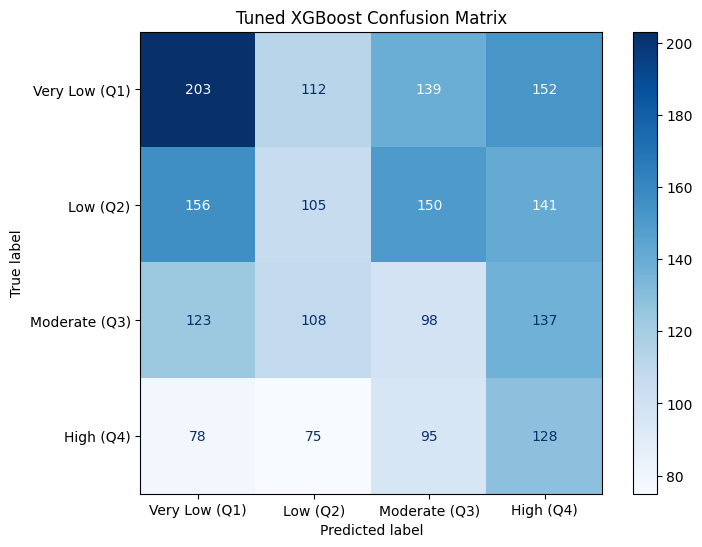

In [44]:
cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1, 2, 3])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Very Low (Q1)", "Low (Q2)", "Moderate (Q3)", "High (Q4)"]
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Tuned XGBoost Confusion Matrix")
plt.savefig("xgboost_confusion_matrix_tuned.png", dpi=300, bbox_inches="tight")

cm_df = pd.DataFrame(
    cm,
    index=["Very Low (Q1)", "Low (Q2)", "Moderate (Q3)", "High (Q4)"],
    columns=["Very Low (Q1)", "Low (Q2)", "Moderate (Q3)", "High (Q4)"]
)
cm_df.to_csv("xgboost_confusion_matrix_tuned.csv", index=True)

plt.show()

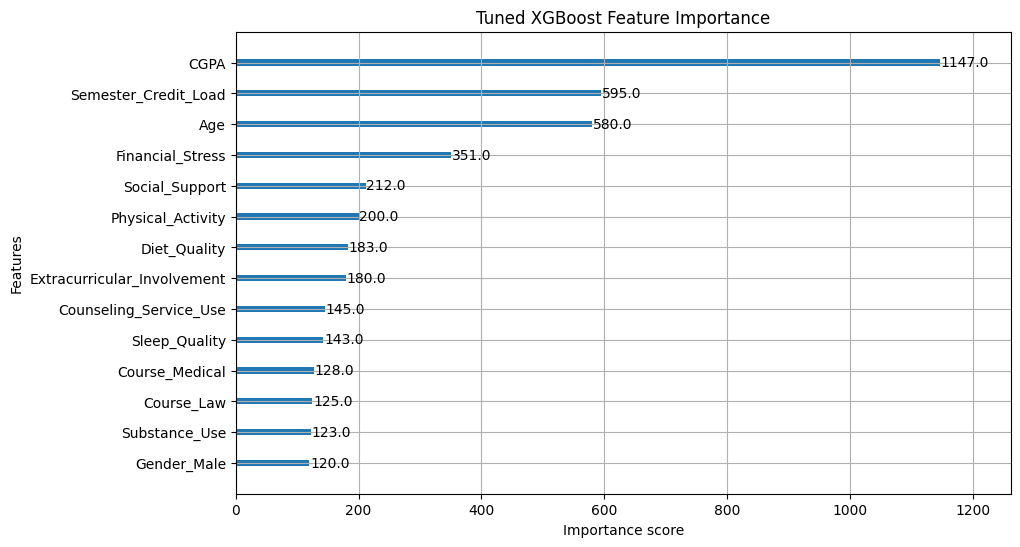

In [45]:
feat_imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

feat_imp_df.to_csv("xgboost_feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(best_xgb, ax=ax, max_num_features=14)
plt.title("Tuned XGBoost Feature Importance")
plt.savefig("xgboost_feature_importance_tuned.png", dpi=300, bbox_inches="tight")
plt.show()